## customer_data
군집 이상치 탐색 (dbscan)

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [59]:
customer = pd.read_csv('gift/customer_segments.csv')
customer.head()

,Customer_ID,Recency_Days,Frequency_90D,Monetary_90D,Avg_Basket,Discount_Ratio,Return_Ratio,Web_Visits_30D,App_Sessions_30D,Review_Score,Region
0,30001,24,9,505714,45856,0.47,0.05,16,10,4.7,Seoul
1,30002,42,2,73314,41320,0.22,0.01,10,4,4.0,Seoul
2,30003,39,10,215402,23642,0.20,0.14,11,14,3.3,Seoul
3,30004,21,4,343927,65800,0.15,0.07,9,3,4.0,Seoul
4,30005,2,19,1633920,70789,0.17,0.05,18,46,4.8,Seoul


In [65]:
# 불필요 컬럼 제거
df = customer.drop(['Customer_ID'], axis=1)

In [66]:
df.head()

,Recency_Days,Frequency_90D,Monetary_90D,Avg_Basket,Discount_Ratio,Return_Ratio,Web_Visits_30D,App_Sessions_30D,Review_Score,Region
0,24,9,505714,45856,0.47,0.05,16,10,4.7,Seoul
1,42,2,73314,41320,0.22,0.01,10,4,4.0,Seoul
2,39,10,215402,23642,0.20,0.14,11,14,3.3,Seoul
3,21,4,343927,65800,0.15,0.07,9,3,4.0,Seoul
4,2,19,1633920,70789,0.17,0.05,18,46,4.8,Seoul


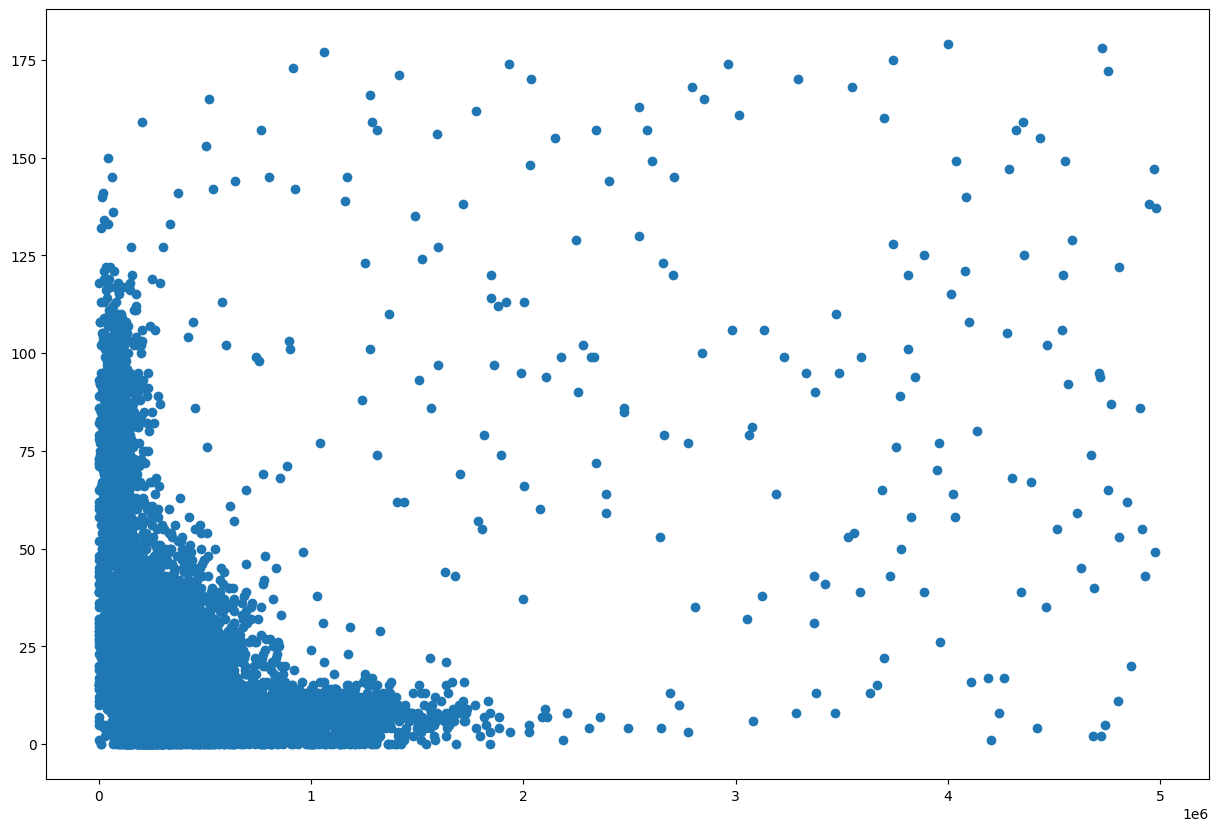

In [68]:
# 시각화하여 분석
plt.figure(figsize=(15,10))
plt.scatter(df['Monetary_90D'], df['Recency_Days'])

plt.show()

In [73]:
# 인코딩하기
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['Region'] = encoder.fit_transform(df['Region'])

In [74]:
# 스케일링

## 이상치 구분이 잘 되는지 확인하기
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# 스케일링
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_data

array([[-0.16783509,  0.17492222,  0.14389001, ..., -0.40930573,
         0.92503672,  1.20903391],
       [ 0.49107745, -1.08431987, -0.63628364, ..., -0.82754257,
        -0.30958019,  1.20903391],
       [ 0.38125869,  0.35481394, -0.37991612, ..., -0.13048118,
        -1.54419711,  1.20903391],
       ...,
       [ 1.77229628, -1.2642116 , -0.66518651, ..., -0.68813029,
        -1.54419711,  0.05399793],
       [-0.57050387, -0.54464469, -0.39765226, ...,  0.21804952,
         0.0431675 ,  0.05399793],
       [-0.68032262, -0.36475296, -0.36804572, ..., -0.06077504,
        -1.36782326,  1.20903391]], shape=(8000, 10))

In [90]:
# 모델 선정
dbscan_model = DBSCAN(eps=1.5, min_samples=5)

# 학습하기 / 예측하기
labels = dbscan_model.fit_predict(scaled_data)
labels

array([0, 0, 0, ..., 0, 0, 0], shape=(8000,))

In [91]:
# 이상치 데이터 (= -1) 개수
(labels ==-1).sum()

np.int64(267)

In [92]:
labels = dbscan_model.fit_predict(scaled_data)
print('이상치 데이터의 개수 :', (labels==-1).sum())

이상치 데이터의 개수 : 267


In [ ]:
set(labels)     # 정상 군집 1

{np.int64(-1), np.int64(0)}

In [98]:
df['cluster'] = labels
df.head()

,Recency_Days,Frequency_90D,Monetary_90D,Avg_Basket,Discount_Ratio,Return_Ratio,Web_Visits_30D,App_Sessions_30D,Review_Score,Region,cluster
0,24,9,505714,45856,0.47,0.05,16,10,4.7,2,0
1,42,2,73314,41320,0.22,0.01,10,4,4.0,2,0
2,39,10,215402,23642,0.20,0.14,11,14,3.3,2,0
3,21,4,343927,65800,0.15,0.07,9,3,4.0,2,0
4,2,19,1633920,70789,0.17,0.05,18,46,4.8,2,0


In [99]:
df['cluster'].value_counts()

cluster
 0    7733
-1     267
Name: count, dtype: int64

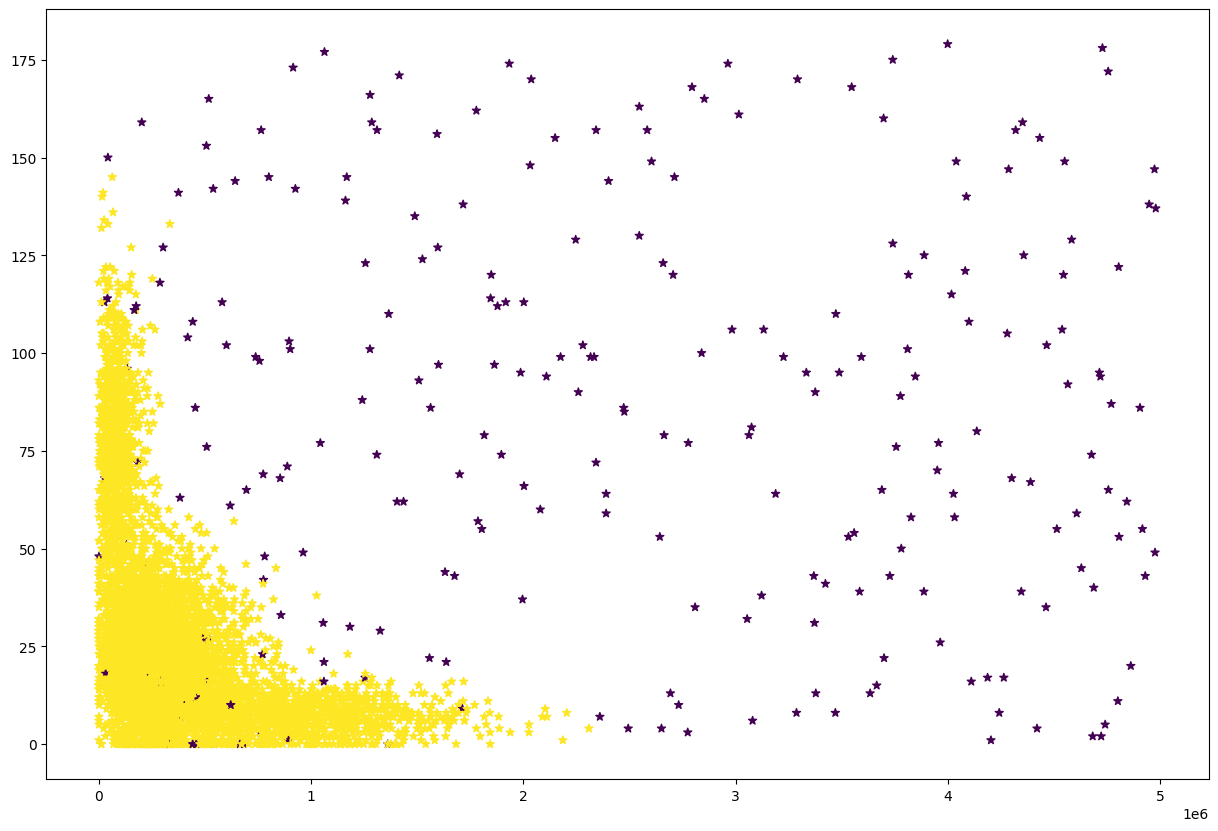

In [103]:
# 시각화(이상치데이터)
plt.figure(figsize=(15,10))
plt.scatter(df['Monetary_90D'], df['Recency_Days'], c=df['cluster'], marker='*')

plt.show()